## Background

**Dataset:** `sklearn.datasets.make_moons`

`make_moons` is a synthetic dataset from `sklearn` that generates a **two-class, two-dimensional** dataset shaped like two half-circles. Because the boundary between classes is curved, **no linear decision boundary can cleanly separate them**. In this lab, we will compare the three different SVM Kernels to see which performs best.



## Step 1: Setup: Load Libraries and Generate Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              RocCurveDisplay, ConfusionMatrixDisplay)

Class distribution:
1    1000
0    1000
Name: count, dtype: int64


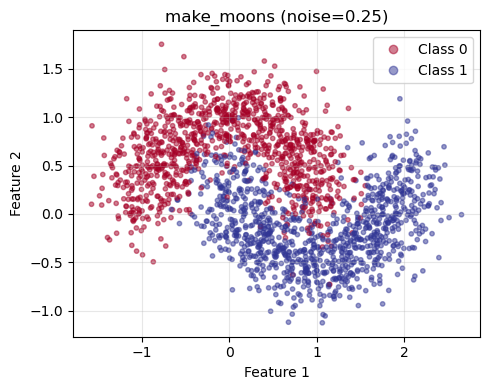

In [2]:

# The `noise` parameter adds Gaussian noise to the coordinates
# Higher noise blurs the boundary and makes the problem harder
# Too little noise makes it trivial

X, y = make_moons(n_samples=2000, noise=0.25, random_state=42)

print(f"Class distribution:\n{pd.Series(y).value_counts()}")

fig, ax = plt.subplots(figsize=(5, 4))
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', s=10, alpha=0.5)
handles, _ = scatter.legend_elements()
ax.legend(handles, ['Class 0', 'Class 1'])
ax.set_title('make_moons (noise=0.25)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The dataset has two features and two balanced classes:

| Feature | Description |
|---------|-------------|
| `X[:, 0]` | x-coordinate (with noise) |
| `X[:, 1]` | y-coordinate (with noise) |



## Step 2: Preprocessing

SVMs are scale-variant, so we always apply `StandardScaler` before fitting. Split your data using `train_test_split` with a test_size of 0.3,  `random_state = 42`, and `stratify = y`. 

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



---

## Background: Support Vector Classifier

The **support vector classifier** (SVC) fits a linear decision boundary by maximizing the margin between classes while allowing some observations to violate it. The penalty hyperparameter `C` controls how harshly violations are penalized:

- **Large C**( 100 to 1000): violations penalized heavily → narrow margin, fewer support vectors, tighter fit to training data
- **Small C** ( 0.0001 to 1): violations tolerated → wide margin, more support vectors, smoother boundary

## Step 3: Tune a Linear SVM with GridSearchCV

---

Use `GridSearchCV` with 5-fold cross-validation, search over the following values of `C` to find the best linear kernel configuration. Report the best parameters, CV accuracy, and test accuracy.

`C`: .001, .01, 0.1, 1, 10, 100



In [4]:
from sklearn.model_selection import GridSearchCV

param_grid_linear = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_linear = GridSearchCV(SVC(kernel='linear'), param_grid_linear, cv=5)
grid_linear.fit(X_train, y_train)


print("Best params:", grid_linear.best_params_)
print("CV accuracy:", grid_linear.best_score_)
print("Test accuracy:", grid_linear.score(X_test, y_test))


Best params: {'C': 1}
CV accuracy: 0.86
Test accuracy: 0.88


##### Look at the accuracy each value of C yielded in `grid_linear`. Hint: You can access the cross validation results using `.cv_results`, then select only the `param_C` and `mean_test_score` column. Convert these results into a DataFrame for easier interpretation!

In [5]:
grid_linear.cv_results_['mean_test_score']


array([0.84714286, 0.85357143, 0.85642857, 0.86      , 0.86      ,
       0.86      ])

> **Q1: What `C` value did cross-validation select? Given that the moons boundary is curved, did you expect the linear kernel to achieve strong accuracy regardless of `C`? At what value of C does the accuracy stop improving?**

It selected at C = 1. This is where accuracy stops improving. I would expect that the linear kernel can only be somewhat accurate because of the shape of our data - I'm surprised it's as high as it is. Given the data cannot be bisected by a single line (given its shape), I would expect limited if not low accuracy.

---

## Background: RBF Kernel

When the true decision boundary is non-linear, we replace the inner product in the SVC formulation with a **kernel function** that implicitly maps observations into a higher-dimensional space. The **radial basis function (RBF)** kernel measures similarity by distance:

$$K(x_i, x_j) = \exp\!\left(-\gamma \|x_i - x_j\|^2\right)$$

The hyperparameter $\gamma$ controls how quickly influence decays with distance:

- **Large $\gamma$** → complex, local boundary (high variance risk)
- **Small $\gamma$** → smooth, global boundary (high bias risk)

Both `C` and `gamma` need to be tuned jointly via cross-validation.

## Step 4: Tune an RBF SVM with GridSearchCV

Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`,search over the following values of `C`,and `gamma` to find the best polynomial kernel configuration. Report the best parameters, CV accuracy, and test accuracy.

`C`: 0.1, 1, 10, 100
`gamma`: `scale`, 0.001, 0.01, 0.1, 1, 10

In [6]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.001, 0.01, 0.1, 1, 10]
}

grid = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("CV accuracy:", grid.best_score_)
print("Test accuracy:", grid.score(X_test, y_test))


Best params: {'C': 1, 'gamma': 1}
CV accuracy: 0.947857142857143
Test accuracy: 0.9383333333333334


> **Q2: How much does the RBF kernel improve over the linear SVM? Do the best `C` and `gamma` values suggest a smooth or tightly-fitted boundary?**

The RBF kernel improves CV accuracy from 0.86 to 0.95, and improved Test accuracy from 0.88 to 0.94. This is an increase of about 10 and 7% respectively. The optimal C value is 1 and the optimal gamma value is also 1. These values are not especially high, but they're not particularly low either. Their moderate values suggest a relatively smooth curved boundary. Given the accuracy on the test set, it's reasonable to assume our model is not over-fitting the training data. 

---

## Background: Polynomial Kernel

The **polynomial kernel** of degree $d$ is:

$$K(x_i, x_j) = ( \gamma \langle x_i, x_j \rangle + r)^d$$


Higher degree allows the boundary to curve more, capturing complex feature interactions, but also increases the risk of overfitting. The `coef0` term (r in the formula above) weights the influence of lower-degree polynomial terms.

## Step 5: Tune a Polynomial SVM with GridSearchCV

Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`, search over the following values of `C`, `degree`, and `coef0` to find the best polynomial kernel configuration. Report the best parameters, CV accuracy, and test accuracy.

`C`: 0.1, 1, 10, 100
`gamma`: 'scale', 0.001, 0.01, 0.1, 1
`degree`: 2, 3, 4
`coef0`: 0.0, 1.0

In [7]:
param_grid_poly = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.001, 0.01, 0.1, 1],
    'degree': [2, 3, 4],
    'coef0': [0.0, 1.0]
}

grid_poly = GridSearchCV(SVC(kernel='poly'), param_grid_poly, cv=5)
grid_poly.fit(X_train, y_train)

print("Best params:", grid_poly.best_params_)
print("CV accuracy:", grid_poly.best_score_)
print("Test accuracy:", grid_poly.score(X_test, y_test))

Best params: {'C': 1, 'coef0': 1.0, 'degree': 3, 'gamma': 1}
CV accuracy: 0.9450000000000001
Test accuracy: 0.94


> **Q3: Which degree polynomial did GridSearchCV select? How does the polynomial kernel's accuracy compare to the RBF kernel for this crescent-shaped data? Does a higher degree always help, and why or why not?**

GridSearchCV selected a 3rd degree polynomial. The polynomial kernel's test accuracy was marginally higher than the RBF kernel and the CV accuracy was marginally lower than RBF. A higher degree does not always help - a higher degree polynomial means that the model is more flexible, but with more flexibility comes a better chance that the model will over-fit the training data. A very high degree polynomial can curve around training data with more accuracy, but when applied to new data it will likely be fitting to complex patterns that only exist in the training data.

---

## Step 6: Streamlining the Hyperparameter Search

Rather than selecting a kernel first and tuning it separately, we can treat the kernel type itself as a hyperparameter. `GridSearchCV` accepts a list of parameter grids, letting each kernel specify its own relevant parameters in a single joint search. Create a joint search where each search grid we used above is included as a dictionary item, with its specified kernel included. `param_grid_all` should be a list of three dictionaries. Then, Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`, search over the parameter grid you created to find the best configuration. Report the best parameters, CV accuracy, and test accuracy.

In [8]:
param_grid_all = [
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10, 100]
    },

    # 1 over the number of features, times the variance in x
    {
        'kernel': ['rbf'],
        'gamma': ['auto', .001, .01, 0.1, 1, 10],
        'C': [0.1, 1, 10, 100]
    },
    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 0.001, .01, 0.1, 1],
        'degree': [2, 3, 4],
        'coef0': [0, 1]
    },
        ]

grid_overall = GridSearchCV(
    SVC(random_state=42),
    param_grid= param_grid_all,
    cv = 5,
    scoring = "accuracy",
    n_jobs = -1
)

grid_overall.fit(X_train, y_train)

best_overall = grid_overall.best_estimator_

test_acc_overall = accuracy_score(y_test, best_overall.predict(X_test))

print(f"Best params: {grid_overall.best_params_}")
print(f"CV Accuracy: {grid_overall.best_score_:.3f}")

print(f"Test Accuracy: {test_acc_overall:.3f}")

Best params: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
CV Accuracy: 0.948
Test Accuracy: 0.938


> **Q4: Which kernel did the overall search select as best? Is this consistent with the cross validation accuracy from the individual kernel results? Given the curved, crescent-shaped structure of the moons data, does the winning kernel make intuitive sense?**

The overall search selected the RBF kernel. This makes sense because of all of the tests we ran, the RBF kernel had the highest CV accuracy. My initial intuition is that the Polynomial would perform better because the data looks like it could be separated by a sine wave, which I think a polynomial function would be good for. However, I also know that RBF is most effective for datasets where categories are grouped closely together (not interspersed), and since our data doesn't have much interspersion, RBF makes a perfectly appropriate intuitive choice.

---


## Step 7: Tune a Random Forest with GridSearchCV

Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`, search over the following values of `n_estimators`, `max_depth`, and `min_samples_leaf` to find the best random forest configuration. Report the best parameters, CV accuracy, and test accuracy.

`n_estimators`: 100, 200
`max_depth` : None, 5, 10
`min_samples_leaf`: 1, 5, 10

In [9]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_leaf': [1, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv = 5,
    scoring = "accuracy",
    n_jobs = -1,
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
test_acc_rf = accuracy_score(y_test, best_rf.predict(X_test))

print(f"Best params: {grid_rf.best_params_}")
print(f"CV Accuracy: {grid_rf.best_score_:.3f}")

print(f"Test Accuracy: {test_acc_rf:.3f}")

Best params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 100}
CV Accuracy: 0.946
Test Accuracy: 0.938


> **Q5:  How does the Random Forest test accuracy compare to the best SVM kernel?**

The random forest accuracy is identical to the best SVM kernel accuracy. 

---

## Step 8: Visualize Decision Boundaries

Because `make_moons` has only two features, we can plot the full decision region for all four models. This is where the differences between kernels and the tree-based approach become visually obvious. Create four visualizations of the decision boundaries for each model above. Use  `DecisionBoundaryDisplay.from_estimator()` to create the visualizations. Add a title specifying the model/kernel used to each plot. 

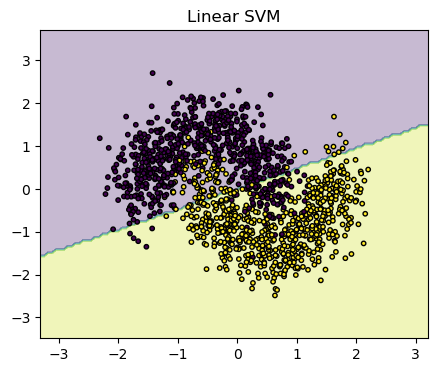

In [10]:
fig, ax = plt.subplots(figsize = (5,4))
DecisionBoundaryDisplay.from_estimator(grid_linear.best_estimator_, X_train, ax = ax, response_method="predict", alpha = 0.3)
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=10, edgecolors='k')
ax.set_title("Linear SVM")
plt.show()

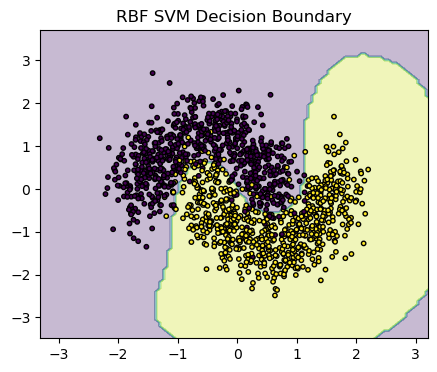

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
DecisionBoundaryDisplay.from_estimator(grid.best_estimator_, X_train, ax=ax, response_method="predict", alpha=0.3)
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=10, edgecolors='k')
ax.set_title("RBF SVM Decision Boundary")
plt.show()

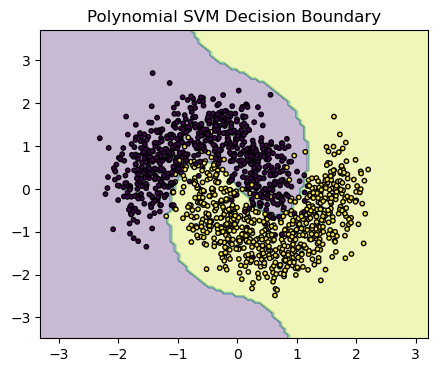

In [14]:
fig, ax = plt.subplots(figsize = (5,4))
DecisionBoundaryDisplay.from_estimator(grid_poly.best_estimator_, X_train, ax = ax, response_method="predict", alpha = 0.3)
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=10, edgecolors='k')
ax.set_title("Polynomial SVM Decision Boundary")
plt.show()

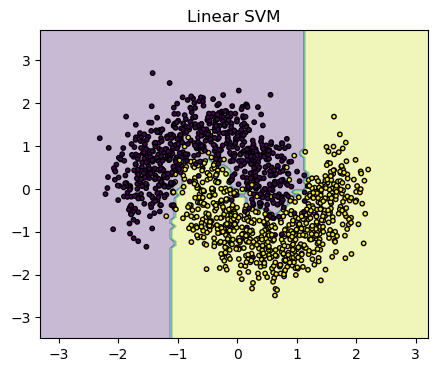

In [15]:
fig, ax = plt.subplots(figsize = (5,4))
DecisionBoundaryDisplay.from_estimator(grid_rf.best_estimator_, X_train, ax = ax, response_method="predict", alpha = 0.3)
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=10, edgecolors='k')
ax.set_title("Linear SVM")
plt.show()

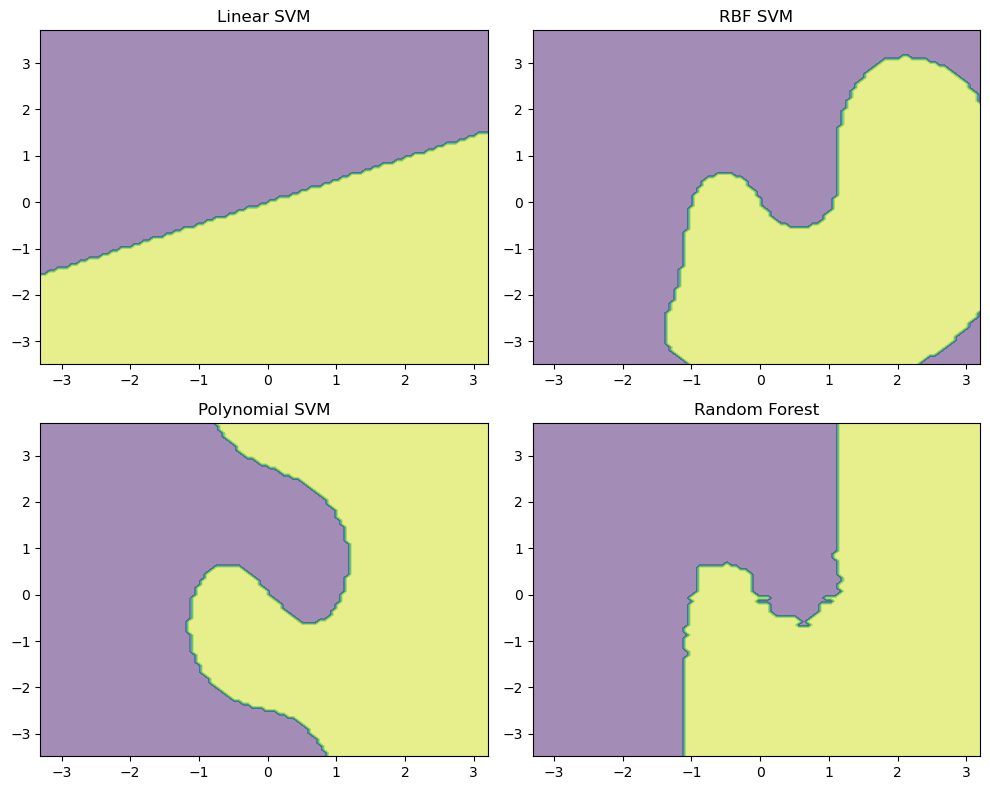

In [ ]:

# Plot all models together

models = {
    'Linear SVM': grid_linear,
    'RBF SVM': grid,
    'Polynomial SVM': grid_poly,
    'Random Forest': grid_rf
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (name, model) in zip(axes.flatten(), models.items()):
    DecisionBoundaryDisplay.from_estimator(model, X_train, ax=ax, response_method='predict', alpha = 0.5)
    ax.set_title(name)

plt.tight_layout()
plt.show()

> **Q6: How does the linear kernel's decision boundary compare visually to the RBF, polynomial, and Random Forest boundaries? How does the Random Forest boundary differ from the SVM boundaries?**


The linear kernel's boundary is a line, which is disctintly different from the curved shape of the RBF and polynomial. The RBF boundary looks like an asymmetrical blob, whereas the polynomial boundar is more symmetrical and really takes on the shape of the data. The random forest boundary is significantly more jagged than the RBF and Polynomial boundaries. It also appears to "reach out" and catch points near the category border better than the SVM methods.

---

## Step 9: Model Comparison


### Confusion Matrices 

Accuracy alone can hide where models differ in their error patterns. Confusion matrices break down false positives and false negatives. 

##### Create a confusion matrix for each of the four models above. 

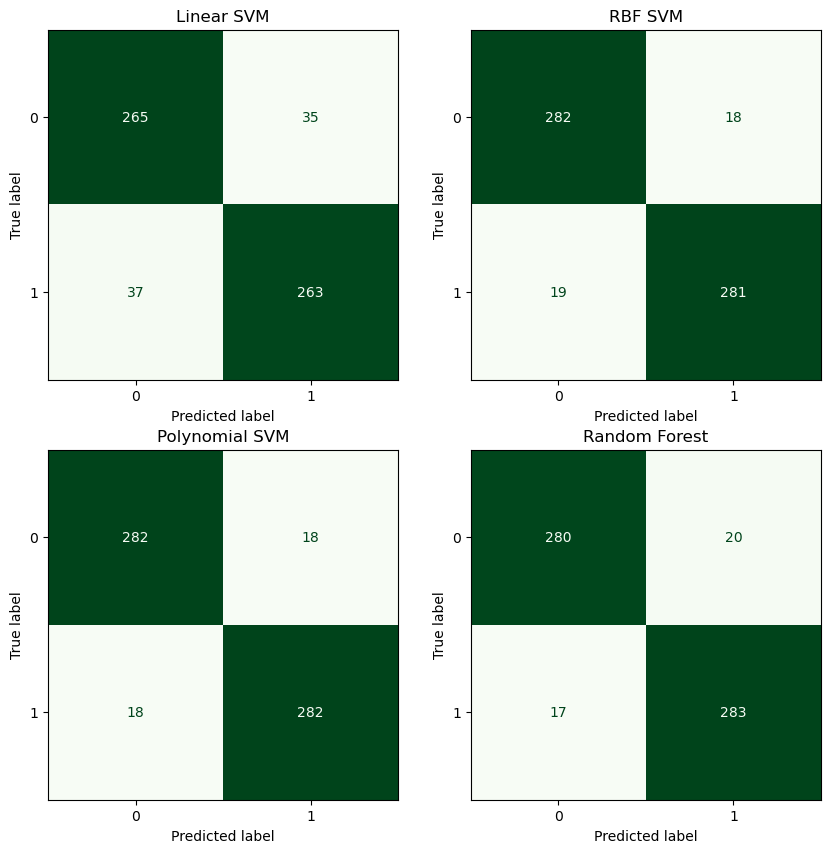

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize = (10, 10))
for ax, (name, model) in zip(axes.flatten(), models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=model.best_estimator_.classes_).plot(ax = ax, cmap = "Greens", colorbar = False)
    ax.set_title(name)

>**Q7:Comment on the results of the confusion matrices. Did all four models have similar misclassifications?**

The linear model had significantly more missclassifications than the other three. RBF, polynomial and random forest all had remarkably similar misclassifications. However, the polynomial SVM had the exact same numer of total positive and total negatives for each category. This was not true for RBF or Random Forest.

### ROC Curves

The **ROC (Receiver Operating Characteristic)** curve plots the true positive rate against the false positive rate as the classification threshold varies. A random classifier follows the diagonal (AUC = 0.50); a perfect classifier has AUC = 1.0.

**AUC (Area Under the Curve)** summarizes the entire ROC curve in a single number that makes it easy to compare different models.

**How ROC works for SVMs specifically:**
Unlike logistic regression, a standard SVC does not output class probabilities. Instead, it computes a decision function — the signed distance of each observation from the decision boundary. Points far on the positive side get large positive scores; points far on the negative side get large negative scores. `RocCurveDisplay.from_estimator` uses this decision function to build the ROC curve.

This means the ROC curve reflects how well each kernel's decision function ranks observations, independent of where the hard boundary is drawn.

##### Plot the ROC Curves for each of the four models on the same plot. Add a line indicating a random classifier (ACU = 0.5) and a legend. 


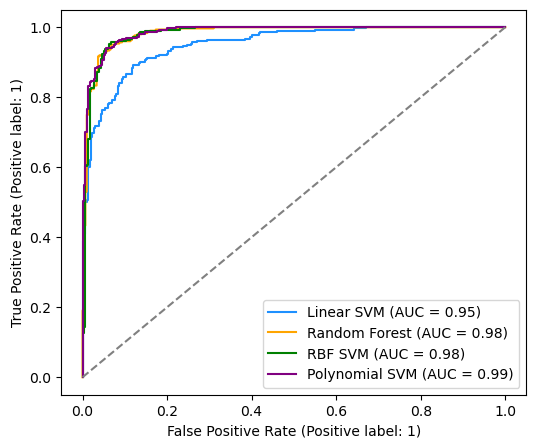

In [26]:
fig, ax = plt.subplots(figsize = (6,5))
RocCurveDisplay.from_estimator(grid_linear.best_estimator_, X_test, y_test, name = "Linear SVM", ax = ax, color = 'DodgerBlue')
RocCurveDisplay.from_estimator(grid_rf.best_estimator_, X_test, y_test, name = "Random Forest", ax = ax, color = 'Orange')
RocCurveDisplay.from_estimator(grid.best_estimator_, X_test, y_test, name = "RBF SVM", ax = ax, color = 'Green')
RocCurveDisplay.from_estimator(grid_poly.best_estimator_, X_test, y_test, name = "Polynomial SVM", ax = ax, color = 'Purple')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='AUC = 0.5')

> **Q8: Do the AUC values align with what you observed in the confusion matrices and accuracy scores? How does the Random Forest compare to the SVM kernels across all three metrics? Considering accuracy, AUC, and the decision boundary shape, which model would you choose for this dataset and why?**

These AUC values do align with what I observed in the confusion matrices and accuracy scores. The random forest, polynomial, and RBF have similar curve shapes and AUC, all of which are significantly higher than the Linear SVM. Given that the polynomial model has balance in missclassifications (18 in each category), it has very similar high accuracy to RF and RBF, and it has the highest AUC, I would select this model for my dataset. I think that the polynomial is most accurately catching the symmetric pattern in the data to great success. 

>**Q9: In terms of overall perforamnce, why does the linear kernel not perform as well as the RBF kernel, Polynomial Kernel, or Random Forest. What is a difference between these latter three models and the former that impacts the shape of the decision boundary and overall accuracy.**

The linear kernel is using a very rigid boundary that cannot accurately separate groups that are not linearly separable. The latter three models are designed to create non-linear boundaries, which allows them to separate data that is curved like the crescent moons data.